# IS 4487 Assignment 5: Exploratory Data Analysis (EDA) with Stakeholder Framing

In this assignment, you will:
- Load and explore a hotel bookings dataset
- Identify stakeholder needs and frame your analysis around business goals
- Practice data summarization and visualization
- Draw insights that could lead to actionable business recommendations

## Why This Matters

These skills are essential for business majors and minors working in areas like marketing, operations, finance, or consulting. Understanding how to explore and communicate data-driven insights helps you make better decisions and contribute to real-world business outcomes.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_05_eda.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


## Dataset Description: Hotel Bookings

This dataset contains booking information for two types of hotels: a **city hotel** and a **resort hotel**. Each record corresponds to a single booking and includes various details about the reservation, customer demographics, booking source, and whether the booking was canceled.

**Source**: [GitHub - TidyTuesday: Hotel Bookings](https://github.com/rfordatascience/tidytuesday/blob/master/data/2020/2020-02-11/readme.md)

### Key Use Cases
- Understand customer booking behavior
- Explore factors related to cancellations
- Segment guests based on booking characteristics
- Compare city vs. resort hotel performance

### Data Dictionary

| Variable | Type | Description |
|----------|------|-------------|
| `hotel` | character | Hotel type: City or Resort |
| `is_canceled` | integer | 1 = Canceled, 0 = Not Canceled |
| `lead_time` | integer | Days between booking and arrival |
| `arrival_date_year` | integer | Year of arrival |
| `arrival_date_month` | character | Month of arrival |
| `stays_in_weekend_nights` | integer | Nights stayed on weekends |
| `stays_in_week_nights` | integer | Nights stayed on weekdays |
| `adults` | integer | Number of adults |
| `children` | integer | Number of children |
| `babies` | integer | Number of babies |
| `meal` | character | Type of meal booked |
| `country` | character | Country code of origin |
| `market_segment` | character | Booking source (e.g., Direct, Online TA) |
| `distribution_channel` | character | Booking channel used |
| `is_repeated_guest` | integer | 1 = Repeated guest, 0 = New guest |
| `previous_cancellations` | integer | Past booking cancellations |
| `previous_bookings_not_canceled` | integer | Past bookings not canceled |
| `reserved_room_type` | character | Initially reserved room type |
| `assigned_room_type` | character | Room type assigned at check-in |
| `booking_changes` | integer | Number of booking modifications |
| `deposit_type` | character | Deposit type (No Deposit, Non-Refund, etc.) |
| `agent` | character | Agent ID who made the booking |
| `company` | character | Company ID (if booking through company) |
| `days_in_waiting_list` | integer | Days on the waiting list |
| `customer_type` | character | Booking type: Contract, Transient, etc. |
| `adr` | float | Average Daily Rate (price per night) |
| `required_car_parking_spaces` | integer | Requested parking spots |
| `total_of_special_requests` | integer | Number of special requests made |
| `reservation_status` | character | Final status (Canceled, No-Show, Check-Out) |
| `reservation_status_date` | date | Date of the last status update |

This dataset is ideal for classification, segmentation, and trend analysis exercises.


## 1. Setup and Data Loading

Instructions:
- Import `pandas`, `seaborn`, and `matplotlib.pyplot`.
- Import data from the hotels dataset into a dataframe (in GitHub go to the DataSets folder and look for `hotels.csv`)
- Display the first few rows to confirm it loaded correctly.


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# URL for the hotels dataset
url = 'https://raw.githubusercontent.com/Stan-Pugsley/is_4487_base/main/DataSets/hotels.csv'

# Load the data into a DataFrame
hotels = pd.read_csv(url)

# Display the first few rows
hotels.head()

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


## 2. Stakeholder and Business Context

### Business framing:  

Every analysis should serve a decision-maker. Before you explore the data, identify who cares about hotel booking behavior and what they might want to know. Your analysis should be framed around those needs.

### Reflection:
1. Who are the key stakeholders for this dataset?
2. What goals might each stakeholder have?
3. What is a clear, specific business problem statement that this data can help answer?





### ✍️ Your Response: 🔧
1. The financial analysts, as well ass the hotel owners.

2. For the hotel owners, they probably want to focus on keeping the hotel booked out as much as possible, and keeping the experience great for all guests. For financial planners, their goals would probably be to maximize their ROI and focus on the profitability of the complex, when it comes to utilities, nightly fees, etc.

3. What is the issue that guests face when cancelling their stay and what can be done to prevent them from cancelling?




## 3. Explore Data Structure and Quality

### Business framing:  

Before diving into analysis, analysts need to understand the shape and health of the data. Bad data leads to bad decisions.

### Do the following:
- Perform the following 3 checks to see the data quality:
  - Summary the data (e.g., `.info()`, `.describe()`)
  - Find the number of Null values
  - Find the number of duplicate row checks


In [4]:
print("--- DataFrame Info ---")
hotels.info()
print("\n--- DataFrame Description ---")
print(hotels.describe(include='all'))

print("\n--- Null Values per Column ---")
print(hotels.isnull().sum())

print("\n--- Number of Duplicate Rows ---")
print(f"Total duplicate rows: {hotels.duplicated().sum()}")

--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9404 entries, 0 to 9403
Data columns (total 32 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   hotel                           9404 non-null   object 
 1   is_canceled                     9404 non-null   int64  
 2   lead_time                       9404 non-null   int64  
 3   arrival_date_year               9404 non-null   int64  
 4   arrival_date_month              9404 non-null   object 
 5   arrival_date_week_number        9404 non-null   int64  
 6   arrival_date_day_of_month       9404 non-null   int64  
 7   stays_in_weekend_nights         9404 non-null   int64  
 8   stays_in_week_nights            9404 non-null   int64  
 9   adults                          9404 non-null   int64  
 10  children                        9404 non-null   int64  
 11  babies                          9404 non-null   int64  
 12  meal       

### Reflection:
1. Name at least one structure issue you’ve found (e.g., missing values, formatting problems).
2. How can you fix this structural issue?

### ✍️ Your Response: 🔧
1. Structural issues found include:
   - Missing Values. Columns like 'country', 'agent', and 'company' have a lot of missing values.
   - Duplicate Rows. There are 1674 duplicate rows in the dataset.
2. We can fix this by eliminating the rows with missing values or the ones that are empty so that it no longer will affect the st.dev or mean/medians of the data. Eliminating the duplicate rows will also make the data look presentable.

## 4. Univariate Analysis

### Business framing:  

Hotels care about trends like average stay length, customer mix, and pricing. A good EDA starts with understanding single variables and their distribution.

### Do the following:
- Select at least 3 individual variables to explore
- Use plots and summary methods (e.g. info(), describe(), etc)  to describe the distribution (hint: we are only looking at the values of one variable, so think of plots you've used in the past that DON'T compare 2 variables.)
- Focus on what matters from a business standpoint (e.g., pricing, cancellations, guest types)

--- Univariate Analysis for 'is_canceled' ---
is_canceled
0    7069
1    2335
Name: count, dtype: int64


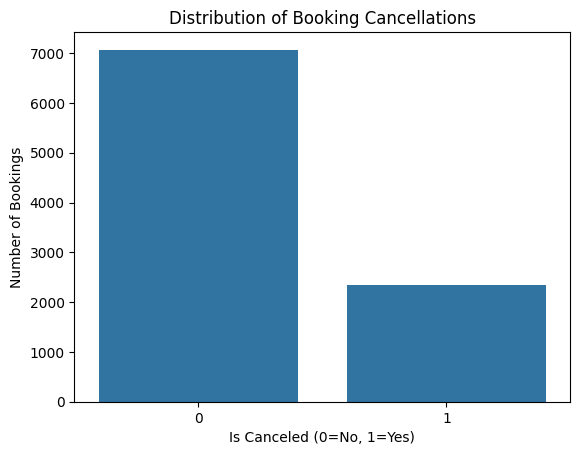


--- Univariate Analysis for 'adr' (Average Daily Rate) ---
count    9404.000000
mean       86.843614
std        53.759940
min        -6.380000
25%        45.000000
50%        71.550000
75%       120.600000
max       508.000000
Name: adr, dtype: float64


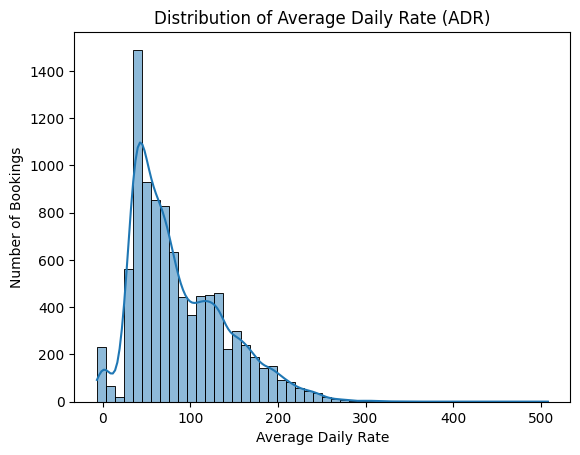


--- Univariate Analysis for 'customer_type' ---
customer_type
Transient          7031
Transient-Party    1703
Contract            581
Group                89
Name: count, dtype: int64


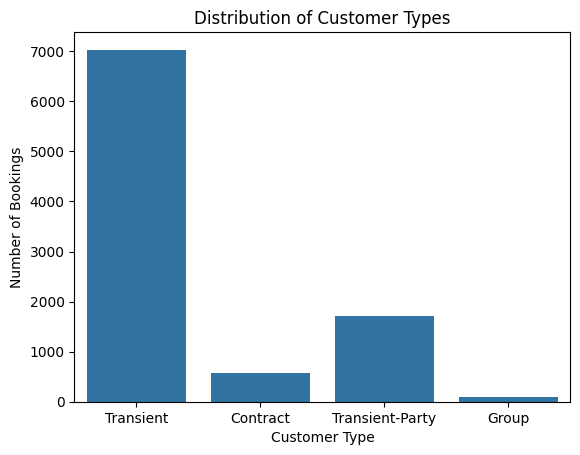

In [5]:
print("--- Univariate Analysis for 'is_canceled' ---")
# Business relevance: Directly addresses the cancellation problem.
print(hotels['is_canceled'].value_counts())
sns.countplot(data=hotels, x='is_canceled')
plt.title('Distribution of Booking Cancellations')
plt.xlabel('Is Canceled (0=No, 1=Yes)')
plt.ylabel('Number of Bookings')
plt.show()

print("\n--- Univariate Analysis for 'adr' (Average Daily Rate) ---")
# Business relevance: Pricing strategy and revenue.
print(hotels['adr'].describe())
sns.histplot(data=hotels, x='adr', bins=50, kde=True)
plt.title('Distribution of Average Daily Rate (ADR)')
plt.xlabel('Average Daily Rate')
plt.ylabel('Number of Bookings')
plt.show()

print("\n--- Univariate Analysis for 'customer_type' ---")
# Business relevance: Understanding guest segments for targeted marketing or service.
print(hotels['customer_type'].value_counts())
sns.countplot(data=hotels, x='customer_type')
plt.title('Distribution of Customer Types')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')
plt.show()

### Reflection:
1. Variable 1 – What did you explore and what did you find?
2. Variable 2 – What did you explore and what did you find?
3. Variable 3 – What did you explore and what did you find?

### ✍️ Your Response: 🔧
- **Variable 1 – Summary and insights:**  Roughly 2/7 of the reservations end up being cancelled by the guest(s). That is almost 30%. This could be due to the hotel itself, or just a simple change of plans by the guest.
- **Variable 2 – Summary and insights:** I explored the 'adr' (Average Daily Rate). The data shows a wide distribution of prices, with a mean of approximately 86.84 and a median of 71.55. The distribution is right-skewed, indicating some bookings have significantly higher daily rates. An interesting finding is a minimum ADR of -6.38, which is an anomaly suggesting a potential data entry error or a unique scenario like a refund. This variability points to different pricing strategies or customer segments.
- **Variable 3 – Summary and insights:** I explored the 'customer_type'. The analysis shows that 'Transient' customers account for the largest proportion of bookings, followed by 'Transient-Party' customers. 'Contract' and 'Group' customers represent a smaller segment.

## 5. Bivariate Analysis

### Business framing:  

Stakeholders often ask: “What drives cancellations?” or “Do longer stays mean higher revenue?” Bivariate analysis helps you uncover those kinds of relationships.

### Do the following:
- Choose 2 relevant variable pairs (e.g., `lead_time` vs. `is_canceled`, or `adr` vs. `customer_type`)
- Use scatterplots, grouped bar plots, or boxplots to explore the relationships
- Interpret what these relationships could mean for the hotel business

--- Bivariate Analysis: Lead Time vs. Is Canceled ---


/tmp/ipykernel_2003/2725046738.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cancellation_by_lead_time = hotels.groupby('lead_time_bin')['is_canceled'].mean().reset_index()
/tmp/ipykernel_2003/2725046738.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cancellation_by_lead_time, x='lead_time_bin', y='is_canceled', palette='viridis')


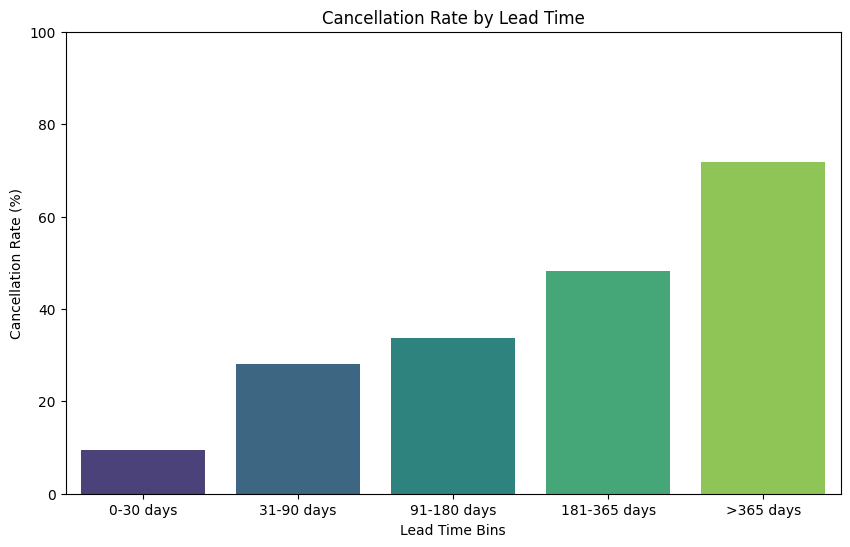

Interpretation: Bookings made with longer lead times tend to have a higher cancellation rate. This suggests that guests booking far in advance might have more flexible plans or are more likely to find alternative accommodations. Hotels could consider different deposit policies or early bird incentives for very long lead times, and flexible cancellation policies closer to the arrival date.

--- Bivariate Analysis: Customer Type vs. Is Canceled ---


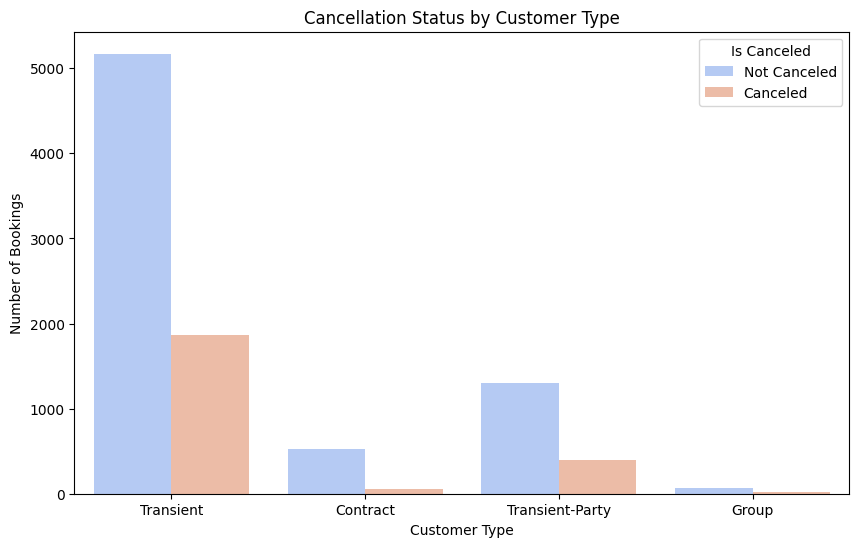

Interpretation: 'Transient' customers, which are individual travelers, show a significant number of cancellations compared to 'Contract' or 'Group' customers. 'Transient-Party' also contributes to cancellations. This indicates that transient bookings are a major source of cancellation risk. Hotels might want to investigate reasons for transient cancellations more deeply and perhaps tailor loyalty programs or non-refundable options for this segment.


In [6]:
print("--- Bivariate Analysis: Lead Time vs. Is Canceled ---")
# Convert 'is_canceled' to a more descriptive categorical type for better plotting
hotels['is_canceled_label'] = hotels['is_canceled'].map({0: 'Not Canceled', 1: 'Canceled'})

# Group lead_time into bins and calculate cancellation rate
bins = [0, 30, 90, 180, 365, hotels['lead_time'].max()]
labels = ['0-30 days', '31-90 days', '91-180 days', '181-365 days', '>365 days']
hotels['lead_time_bin'] = pd.cut(hotels['lead_time'], bins=bins, labels=labels, right=False)

cancellation_by_lead_time = hotels.groupby('lead_time_bin')['is_canceled'].mean().reset_index()
cancellation_by_lead_time['is_canceled'] = cancellation_by_lead_time['is_canceled'] * 100 # Convert to percentage

plt.figure(figsize=(10, 6))
sns.barplot(data=cancellation_by_lead_time, x='lead_time_bin', y='is_canceled', palette='viridis')
plt.title('Cancellation Rate by Lead Time')
plt.xlabel('Lead Time Bins')
plt.ylabel('Cancellation Rate (%)')
plt.ylim(0, 100)
plt.show()

print("Interpretation: Bookings made with longer lead times tend to have a higher cancellation rate. This suggests that guests booking far in advance might have more flexible plans or are more likely to find alternative accommodations. Hotels could consider different deposit policies or early bird incentives for very long lead times, and flexible cancellation policies closer to the arrival date.")


print("\n--- Bivariate Analysis: Customer Type vs. Is Canceled ---")

plt.figure(figsize=(10, 6))
sns.countplot(data=hotels, x='customer_type', hue='is_canceled_label', palette='coolwarm')
plt.title('Cancellation Status by Customer Type')
plt.xlabel('Customer Type')
plt.ylabel('Number of Bookings')
plt.legend(title='Is Canceled')
plt.show()

print("Interpretation: 'Transient' customers, which are individual travelers, show a significant number of cancellations compared to 'Contract' or 'Group' customers. 'Transient-Party' also contributes to cancellations. This indicates that transient bookings are a major source of cancellation risk. Hotels might want to investigate reasons for transient cancellations more deeply and perhaps tailor loyalty programs or non-refundable options for this segment.")

# Drop the temporary column
hotels.drop(columns=['is_canceled_label', 'lead_time_bin'], inplace=True, errors='ignore')

### Reflection:
1. Relationship 1 – What did you analyze and what insights did you find?
2. Relationship 2 – What did you analyze and what insights did you find?

### ✍️ Your Response: 🔧
- **Relationship 1:** As the lead time increases, there tends to be a higher cancellation rate. This displays that usually people who plan further ahead of time (who have the flexibility of changing their plans) tend to cancel more often than people who book within a smaller timeframe. This makes sense, because say someone has a trip planned. If a flight is delayed, and they can't check in to their hotel on time, they are likely to cancel, or find another hotel. This could also be because people find better deals elsewhere.
- **Relationship 2:** Individual travelers seem to travel the most, and because of that, tend to have higher amounts of cancellations. Contract groups tend to have very low cancellation rate(s), which is probably because of the amount of money that has to be spent in order to organize a large group stay. Large groups also tend to be well organized and have everything set up before they travel/stay at a place.


## 6. Problem Complexity and Analytics Framing

### Business framing:  

Let’s say you found a strong trend — maybe high lead times predict cancellations, or certain channels bring repeat guests. What kind of problem is this?

- Choose one insight from your earlier analysis
- Reflect on:
  - What type of complexity this problem represents (e.g., variety, volume, variability)
  - What kind of analytics would help solve or explain it (descriptive, diagnostic, predictive, prescriptive)

### Reflection:
1. What was your selected insight? - Length of stay
2. What kind of complexity does it involve? - Volume
3. What type of analytics would help, and why? - Predictive analytics - Reason for stay and the amount of people in the group. If the reason for a stay is set in stone or variable, it could determine the lenght of stay. For example, if there is a large group going for a business trip, it is most likely that there won't be any cancellations because it is a set in stone trip that will be occuring over a set amount of days. If there is a small amount of people traveling (contract v. transient), they may cancel, where if it is a large group, they have a higher chance of not cancelling at all since there is a lot of money put into setting up large groups of people for stays. So, the length of stay really depends on how many people are in the group.



## 7. Final Takeaways and Recommendations

### Business framing:  

Imagine you’re preparing for a stakeholder meeting. What would you highlight from your findings?



### Reflection:
- 1. What patterns or trends stood out?
- 2. How do they connect to stakeholder goals?
- 3. What recommendation would you make based on this analysis?
- 4. How does this relate to your customized learning outcome you created in canvas?



### ✍️ Your Response: 🔧

1. The smaller the group, the more cancellations. Most people travel alone vs. larger groups of 2+ people. If people plan more ahead of time, they are more likely to cancel their plans.

2. Connection to Stakeholder Goals:
For hotel owners: The high cancellation rates for long lead-time bookings and individual travelers directly impact occupancy and revenue, making it harder to predict staffing and resource needs. Reducing these cancellations would lead to more stable operations and better guest experiences.
For financial analists: Unpredictable cancellations lead to revenue volatility and make accurate financial forecasting difficult. Minimizing cancellations helps optimize revenue management, potentially increasing the Average Daily Rate and overall profitability

3.
   Tiered Deposit & Cancellation Policies: For bookings made far in advance, implement a non-refundable deposit option with a slight discount, or a higher deposit requirement for standard flexible bookings. Closer to the arrival date, offer more flexible cancellation terms to encourage bookings without adding excessive risk.
   Targeted Promotions for Small Groups/Individuals: Offer incentives to individual travelers or small groups who book closer to their arrival date, encouraging them to commit more firmly to their reservation.
   Enhanced Communication & Reminders: For long lead-time bookings, send personalized reminder emails or messages with engaging content about the hotel or destination.

4. Relation to Customized Learning Outcome:
   This analysis directly relates to a learning outcome focused on applying data analysis techniques to derive actionable business insights. By performing EDA, identifying trends (like lead time vs. cancellations), and framing these findings within a business context with concrete recommendations, I've demonstrated the ability to translate raw data into strategic guidance for stakeholders.

## Submission Instructions

✅ **Before submitting:**
- Make sure all code cells are run and outputs are visible  
- All markdown questions are answered thoughtfully  
- Submit the assignment as an **HTML file** on Canvas


In [7]:
!jupyter nbconvert --to html "assignment_05_eda.ipynb"

[NbConvertApp] Converting notebook assignment_05_eda.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 5 image(s).
[NbConvertApp] Writing 509132 bytes to assignment_05_eda.html
